# Week 1 — Setup, Data Loading & Exploration
### Air Quality Sensor Network Audit — Population-Weighted PM2.5 Exposure vs. Official Monitoring

**Goal:** Select cities, load the three core datasets (CPCB stations, SatPM PM2.5, WorldPop population),
align coordinate systems, and produce initial exploratory maps.

**Note on data:** This notebook is written to work identically whether you have the real project data
package or not. `src/data_loader.py` looks for real files under `data/raw/`; if they're absent, it
generates realistic **synthetic** stand-ins with the same schema, clearly labelled in every printout
and plot title. Once the real data package arrives, drop the files in `data/raw/` (see README in that
folder) and re-run — no code changes needed.


In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import geopandas as gpd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import folium
from folium.plugins import HeatMap

from data_loader import (
    load_cpcb_stations,
    load_satpm_pm25,
    load_worldpop_population,
    get_city_boundary,
    get_all_city_boundaries,
    CITY_REGISTRY,
    SELECTED_CITIES,
)

pd.set_option('display.max_columns', 50)
plt.rcParams['figure.dpi'] = 100
print("Setup complete.")


Setup complete.


## 1. Select NCAP Cities

We pick 4 cities spanning the monitoring-density spectrum required by the problem statement:

| City | Type | Rationale |
|---|---|---|
| **Delhi** | Heavily monitored metro | Dense CAAQMS network (~40 stations) — good baseline for calibration (Weeks 3-5) |
| **Lucknow** | Mid-tier city | Moderate station count, large population — good NCAP funding-relevance case |
| **Patna** | Mid-tier city | Similar tier to Lucknow, different geography/pollution profile — cross-city robustness check |
| **Muzaffarpur** | Small, sparsely monitored NCAP city | Only ~1 official station — the case where the exposure-gap / placement recommendation matters most |

This mix directly supports the project's core question: does monitor placement correlate with where
people actually live and breathe polluted air, or with something else (funding incentives, ease of
access, legacy siting)?


In [2]:
for city, info in CITY_REGISTRY.items():
    marker = " <-- SELECTED" if city in SELECTED_CITIES else ""
    print(f"{city:15s} | type: {info['type']:25s} | expected official stations: "
          f"{info['n_official_stations_expected']:>3d}{marker}")


Delhi           | type: heavily_monitored_metro   | expected official stations:  40 <-- SELECTED
Lucknow         | type: mid_tier_city             | expected official stations:   8 <-- SELECTED
Patna           | type: mid_tier_city             | expected official stations:   6 <-- SELECTED
Muzaffarpur     | type: small_sparse_ncap_city    | expected official stations:   1 <-- SELECTED


## 2. Load CPCB CAAQMS Station List

Extract `station_id`, `station_name`, `city`, `latitude`, `longitude`, and `parameters` monitored
for each selected city. Returned as a `GeoDataFrame` (CRS: EPSG:4326 / WGS84) so it's immediately
mappable and joinable with the raster grids later.


In [3]:
stations_gdf = load_cpcb_stations(cities=SELECTED_CITIES)

print(f"Total stations loaded: {len(stations_gdf)}")
print(f"CRS: {stations_gdf.crs}")
print()
display(stations_gdf.groupby('city').size().rename('n_stations').to_frame())


[data_loader] CPCB station list: SYNTHETIC (fallback) -> (generated in-memory)
Total stations loaded: 55
CRS: EPSG:4326



,n_stations
city,
Delhi,40
Lucknow,8
Muzaffarpur,1
Patna,6


In [4]:
stations_gdf[['station_id', 'station_name', 'city', 'latitude', 'longitude', 'parameters']].head(10)


,station_id,station_name,city,latitude,longitude,parameters
0,SYN-1000,Delhi CAAQMS Station 1,Delhi,28.610662,77.234718,"PM2.5, PM10, NO2, SO2, CO, O3"
1,SYN-1001,Delhi CAAQMS Station 2,Delhi,28.734737,77.277885,"PM2.5, PM10, NO2, SO2, CO, O3"
2,SYN-1002,Delhi CAAQMS Station 3,Delhi,28.868299,76.888030,"PM2.5, PM10, NO2, SO2, CO, O3"
3,SYN-1003,Delhi CAAQMS Station 4,Delhi,28.777311,77.228181,"PM2.5, PM10, NO2, SO2, CO, O3"
4,SYN-1004,Delhi CAAQMS Station 5,Delhi,28.616185,76.905338,"PM2.5, PM10, NO2, SO2, CO, O3"
5,SYN-1005,Delhi CAAQMS Station 6,Delhi,28.844847,77.029107,"PM2.5, PM10, NO2, SO2, CO, O3"
6,SYN-1006,Delhi CAAQMS Station 7,Delhi,28.794926,77.168371,"PM2.5, PM10, NO2, SO2, CO, O3"
7,SYN-1007,Delhi CAAQMS Station 8,Delhi,28.509075,77.066141,"PM2.5, PM10, NO2, SO2, CO, O3"
8,SYN-1008,Delhi CAAQMS Station 9,Delhi,28.430632,77.122838,"PM2.5, PM10, NO2, SO2, CO, O3"
9,SYN-1009,Delhi CAAQMS Station 10,Delhi,28.703199,77.262092,"PM2.5, PM10, NO2, SO2, CO, O3"


**Observation to carry into Week 6:** the huge disparity in station counts (Delhi: ~40 vs.
Muzaffarpur: ~1) is exactly the pattern the project investigates — is that disparity justified by
population and pollution levels, or does it reflect something else?


## 3. Load SatPM V6 Satellite-Derived PM2.5

Monthly gridded PM2.5 surface for each city's bounding box. Returned as an `xarray.DataArray`
(dims: `lat`, `lon`) so it composes naturally with the population grid in Week 2's zonal-statistics step.


In [5]:
SELECTED_MONTH = "2024-01"  # adjust once real SatPM monthly coverage is confirmed

pm25_by_city = {}
for city in SELECTED_CITIES:
    da = load_satpm_pm25(city, month=SELECTED_MONTH)
    pm25_by_city[city] = da
    print(f"{city:15s} | grid shape: {str(da.shape):12s} | "
          f"PM2.5 range: {float(da.min()):6.1f} - {float(da.max()):6.1f} ug/m3 | "
          f"mean: {float(da.mean()):6.1f} ug/m3 | source: {da.attrs['source']}")


[data_loader] SatPM PM2.5 (Delhi, 2024-01): SYNTHETIC (fallback) -> (generated in-memory)
Delhi           | grid shape: (49, 51)     | PM2.5 range:   33.8 -  144.7 ug/m3 | mean:   64.3 ug/m3 | source: SYNTHETIC (SatPM V6 fallback)
[data_loader] SatPM PM2.5 (Lucknow, 2024-01): SYNTHETIC (fallback) -> (generated in-memory)
Lucknow         | grid shape: (27, 30)     | PM2.5 range:   41.6 -  124.3 ug/m3 | mean:   71.2 ug/m3 | source: SYNTHETIC (SatPM V6 fallback)
[data_loader] SatPM PM2.5 (Patna, 2024-01): SYNTHETIC (fallback) -> (generated in-memory)
Patna           | grid shape: (18, 29)     | PM2.5 range:   52.5 -  126.9 ug/m3 | mean:   80.7 ug/m3 | source: SYNTHETIC (SatPM V6 fallback)
[data_loader] SatPM PM2.5 (Muzaffarpur, 2024-01): SYNTHETIC (fallback) -> (generated in-memory)
Muzaffarpur     | grid shape: (15, 19)     | PM2.5 range:   56.7 -  107.0 ug/m3 | mean:   76.5 ug/m3 | source: SYNTHETIC (SatPM V6 fallback)


## 4. Load WorldPop 100m Population Grid

Gridded population counts per cell, same city bounding boxes. This will be combined with the PM2.5
grid in Week 2 to compute population-weighted exposure.


In [6]:
pop_by_city = {}
for city in SELECTED_CITIES:
    da = load_worldpop_population(city)
    pop_by_city[city] = da
    print(f"{city:15s} | grid shape: {str(da.shape):14s} | "
          f"total population: {float(da.sum()):>12,.0f} | source: {da.attrs['source']}")


[data_loader] WorldPop population (Delhi): SYNTHETIC (fallback) -> (generated in-memory)
Delhi           | grid shape: (481, 510)     | total population:   16,965,523 | source: SYNTHETIC (WorldPop fallback)
[data_loader] WorldPop population (Lucknow): SYNTHETIC (fallback) -> (generated in-memory)
Lucknow         | grid shape: (261, 300)     | total population:    3,400,596 | source: SYNTHETIC (WorldPop fallback)
[data_loader] WorldPop population (Patna): SYNTHETIC (fallback) -> (generated in-memory)
Patna           | grid shape: (180, 281)     | total population:    1,999,801 | source: SYNTHETIC (WorldPop fallback)
[data_loader] WorldPop population (Muzaffarpur): SYNTHETIC (fallback) -> (generated in-memory)
Muzaffarpur     | grid shape: (150, 181)     | total population:      399,831 | source: SYNTHETIC (WorldPop fallback)


**Note the resolution mismatch:** SatPM (~0.01°, roughly 1km) and WorldPop (~0.001°, roughly 100m)
grids are on different resolutions and different pixel grids. Week 2's first task is reconciling this
(resampling one to match the other) before the population-weighting can be computed correctly — we
deliberately leave them unaligned here so that step is visible and explicit rather than hidden.


## 5. Coordinate Reference System (CRS) Check

All three datasets should share a common CRS before any spatial join or area-based calculation.
We standardize on **EPSG:4326 (WGS84, lat/lon)** for Week 1 exploration and mapping. For Week 2's
area-accurate zonal statistics, we'll additionally reproject to a local **UTM zone** (UTM 44N,
EPSG:32644, covers all 4 cities) since EPSG:4326 degrees aren't equal-area and would bias
population-weighting near the grid edges.


In [7]:
print("=== CRS audit ===")
print(f"CPCB stations (GeoDataFrame):  {stations_gdf.crs}")

for city in SELECTED_CITIES:
    pm25_crs = pm25_by_city[city].attrs.get('crs', 'not set')
    pop_crs = pop_by_city[city].attrs.get('crs', 'not set')
    print(f"{city:15s} | SatPM CRS: {pm25_crs:12s} | WorldPop CRS: {pop_crs:12s}")

print()
print("Target analysis CRS for Week 2 area-accurate calculations: EPSG:32644 (UTM Zone 44N)")

# Quick check: does UTM 44N reasonably cover all 4 cities without excessive distortion?
utm_test = stations_gdf.to_crs("EPSG:32644")
print(f"\nStations reprojected to UTM 44N successfully. Sample coordinates (meters):")
print(utm_test.geometry.head(3))


=== CRS audit ===
CPCB stations (GeoDataFrame):  EPSG:4326
Delhi           | SatPM CRS: EPSG:4326    | WorldPop CRS: EPSG:4326   
Lucknow         | SatPM CRS: EPSG:4326    | WorldPop CRS: EPSG:4326   
Patna           | SatPM CRS: EPSG:4326    | WorldPop CRS: EPSG:4326   
Muzaffarpur     | SatPM CRS: EPSG:4326    | WorldPop CRS: EPSG:4326   

Target analysis CRS for Week 2 area-accurate calculations: EPSG:32644 (UTM Zone 44N)

Stations reprojected to UTM 44N successfully. Sample coordinates (meters):
0    POINT (131751.431 3170651.031)
1    POINT (136406.054 3184280.189)
2     POINT (98802.712 3200352.613)
Name: geometry, dtype: geometry


## 6. City Boundaries

Simple bounding-box polygons per city for Week 1 (sufficient for clipping/exploration). Ward-level
boundaries — needed for the finer-grained Week 6 placement analysis — should be sourced separately
(Census India shapefiles or city GIS portals); flagged here as a Week 2/6 follow-up.


In [8]:
city_boundaries = get_all_city_boundaries(SELECTED_CITIES)
city_boundaries['area_km2'] = city_boundaries.to_crs("EPSG:32644").geometry.area / 1e6
city_boundaries[['city', 'area_km2']]


,city,area_km2
0,Delhi,2660.163790
1,Lucknow,858.258363
2,Patna,562.874853
3,Muzaffarpur,300.354280


## 7. Exploratory Visualization

### 7a. Station locations on an interactive map (folium)


In [9]:
def make_station_map(city, stations_gdf, city_boundaries):
    city_stations = stations_gdf[stations_gdf['city'] == city]
    center = CITY_REGISTRY[city]['center']

    m = folium.Map(location=center, zoom_start=11, tiles='CartoDB positron')

    # city boundary
    boundary = city_boundaries[city_boundaries['city'] == city]
    folium.GeoJson(
        boundary.geometry.iloc[0],
        style_function=lambda x: {'fillOpacity': 0, 'color': 'gray', 'weight': 1, 'dashArray': '4,4'}
    ).add_to(m)

    # stations
    for _, row in city_stations.iterrows():
        folium.CircleMarker(
            location=[row['latitude'], row['longitude']],
            radius=5,
            color='crimson',
            fill=True,
            fill_opacity=0.8,
            popup=f"{row['station_name']}<br>ID: {row['station_id']}<br>Params: {row['parameters']}",
        ).add_to(m)

    return m

# Example: Delhi station map (swap city name to view others)
delhi_map = make_station_map('Delhi', stations_gdf, city_boundaries)
delhi_map


In [10]:
# Sparse-monitoring case for contrast
muzaffarpur_map = make_station_map('Muzaffarpur', stations_gdf, city_boundaries)
muzaffarpur_map


### 7b. Raw satellite PM2.5 heatmap (per city)

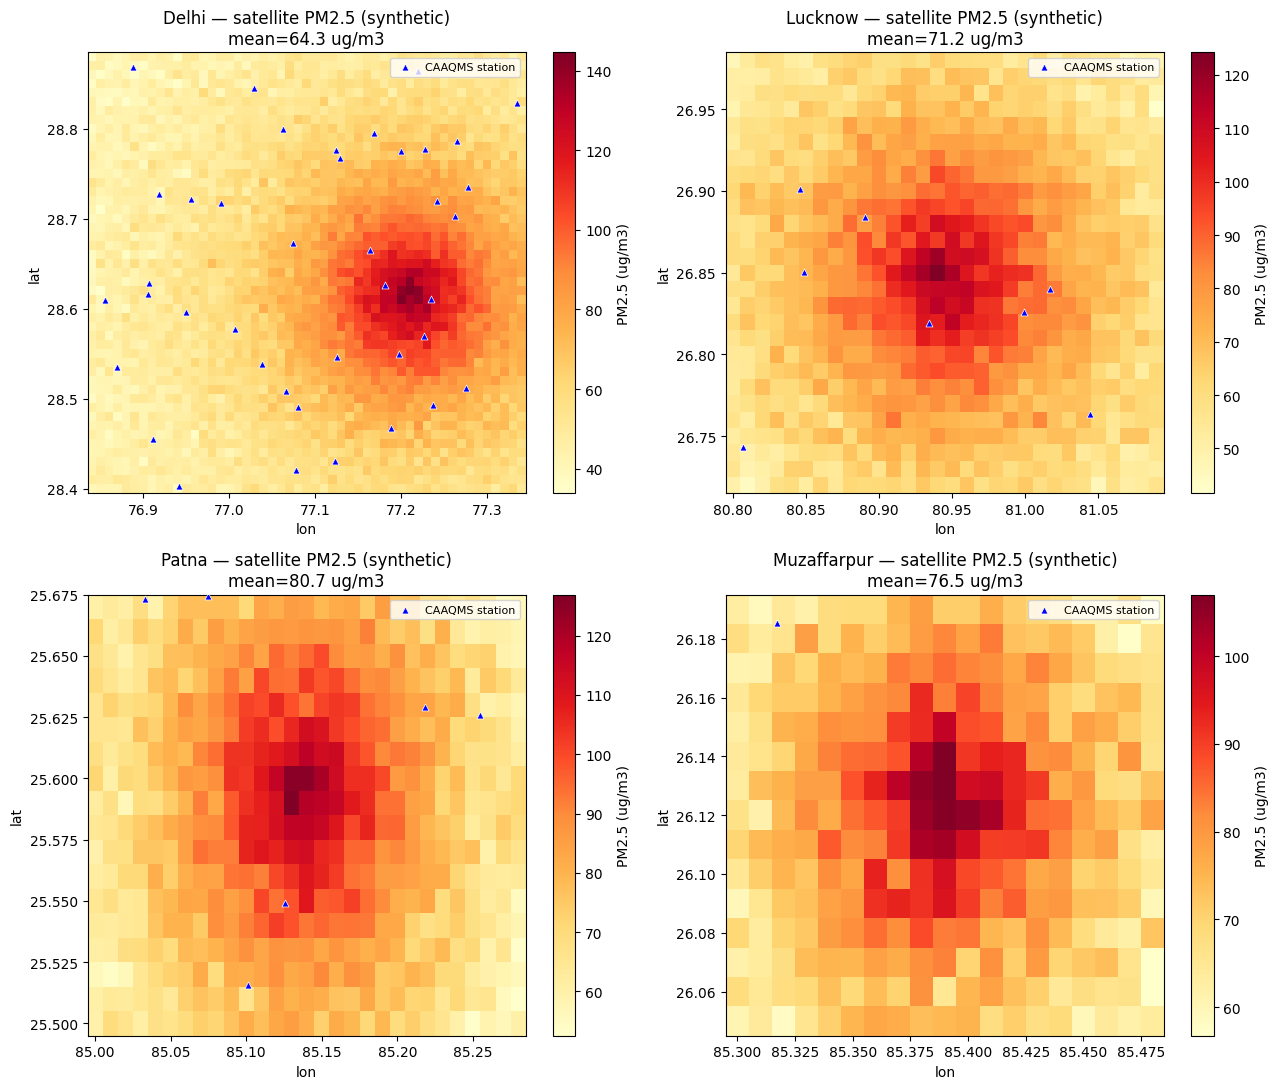

Saved: data/processed/week1_pm25_heatmaps.png


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(13, 11))
axes = axes.flatten()

for ax, city in zip(axes, SELECTED_CITIES):
    da = pm25_by_city[city]
    im = da.plot(ax=ax, cmap='YlOrRd', add_colorbar=True,
                 cbar_kwargs={'label': 'PM2.5 (ug/m3)'})

    city_stations = stations_gdf[stations_gdf['city'] == city]
    ax.scatter(city_stations['longitude'], city_stations['latitude'],
               c='blue', s=25, marker='^', edgecolor='white', linewidth=0.5,
               label='CAAQMS station', zorder=5)

    source_tag = "(synthetic)" if "SYNTHETIC" in da.attrs['source'] else "(real)"
    ax.set_title(f"{city} — satellite PM2.5 {source_tag}\nmean={float(da.mean()):.1f} ug/m3")
    ax.legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.savefig('../data/processed/week1_pm25_heatmaps.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved: data/processed/week1_pm25_heatmaps.png")


### 7c. Population density (per city)

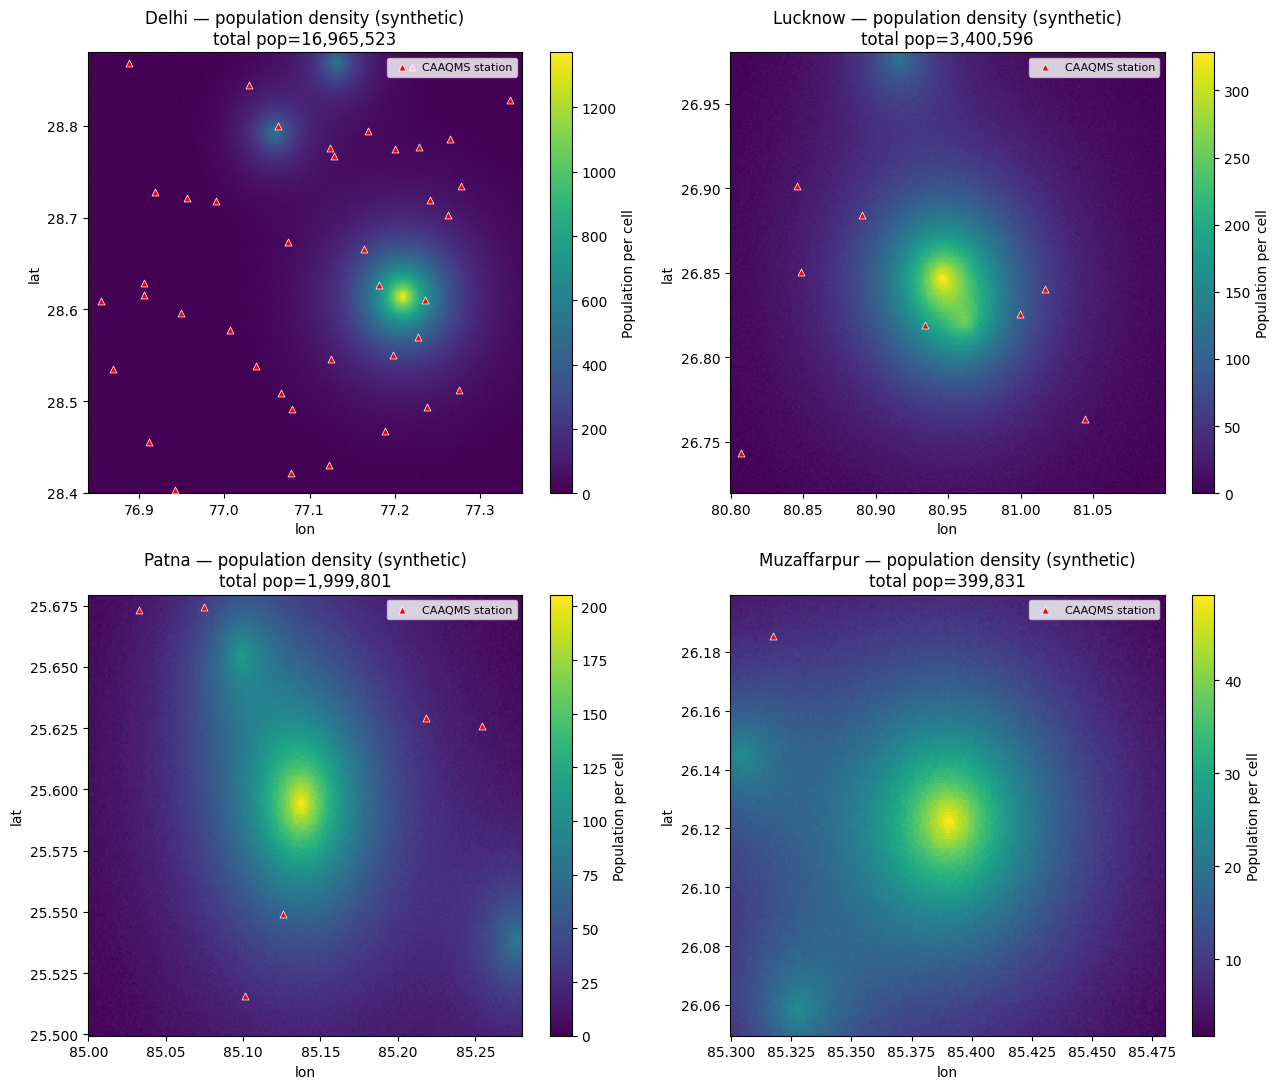

Saved: data/processed/week1_population_heatmaps.png


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(13, 11))
axes = axes.flatten()

for ax, city in zip(axes, SELECTED_CITIES):
    da = pop_by_city[city]
    da.plot(ax=ax, cmap='viridis', add_colorbar=True,
            cbar_kwargs={'label': 'Population per cell'})

    city_stations = stations_gdf[stations_gdf['city'] == city]
    ax.scatter(city_stations['longitude'], city_stations['latitude'],
               c='red', s=25, marker='^', edgecolor='white', linewidth=0.5,
               label='CAAQMS station', zorder=5)

    source_tag = "(synthetic)" if "SYNTHETIC" in da.attrs['source'] else "(real)"
    ax.set_title(f"{city} — population density {source_tag}\ntotal pop={float(da.sum()):,.0f}")
    ax.legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.savefig('../data/processed/week1_population_heatmaps.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved: data/processed/week1_population_heatmaps.png")


### 7d. Side-by-side: pollution vs. population vs. monitor coverage (Delhi example)

This is a preview of the exact comparison the whole project builds toward — visually, do monitors
sit where pollution AND population are both high?


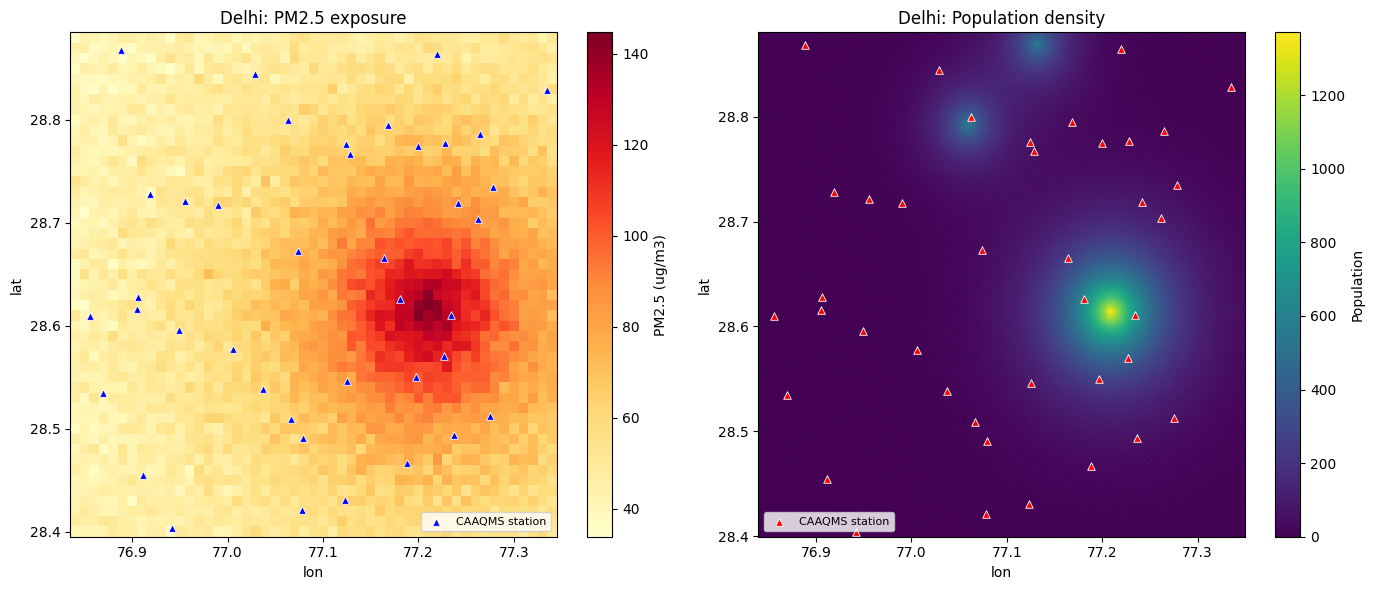

In [13]:
city = "Delhi"
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

pm25_by_city[city].plot(ax=axes[0], cmap='YlOrRd', add_colorbar=True, cbar_kwargs={'label': 'PM2.5 (ug/m3)'})
pop_by_city[city].plot(ax=axes[1], cmap='viridis', add_colorbar=True, cbar_kwargs={'label': 'Population'})

for ax, title in zip(axes, ['PM2.5 exposure', 'Population density']):
    city_stations = stations_gdf[stations_gdf['city'] == city]
    ax.scatter(city_stations['longitude'], city_stations['latitude'],
               c='blue' if title.startswith('PM') else 'red', s=30, marker='^',
               edgecolor='white', linewidth=0.6, label='CAAQMS station', zorder=5)
    ax.set_title(f"{city}: {title}")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


## 8. Week 1 Summary & Handoff to Week 2

**What we have:**
- 4 NCAP cities selected, spanning heavily-monitored to sparsely-monitored
- CPCB station GeoDataFrame (id, name, city, lat/lon, parameters, geometry) — EPSG:4326
- Per-city SatPM PM2.5 grids (xarray DataArray, ~0.01° resolution) — EPSG:4326
- Per-city WorldPop population grids (xarray DataArray, ~0.001° resolution) — EPSG:4326
- City bounding-box boundaries + area calculations (via UTM 44N reprojection)
- Exploratory maps: interactive station maps, PM2.5 heatmaps, population heatmaps

**Flagged for Week 2:**
1. **Resolution mismatch** between SatPM (~1km) and WorldPop (~100m) grids must be resolved
   (resample one to the other's grid) before population-weighted exposure can be computed.
2. **CRS**: reproject both grids to EPSG:32644 (UTM 44N) for area-accurate zonal statistics.
3. Consider sourcing **ward-level boundaries** now if finer granularity is wanted for Week 6.

**Data status:** All datasets are currently **SYNTHETIC** fallbacks generated by `src/data_loader.py`. Replace with real files in `data/raw/` (see module docstring for expected filenames/schemas) and re-run — no other code changes required.


In [14]:
# Persist Week 1 outputs for Week 2 to consume
import pickle

week1_outputs = {
    'stations_gdf': stations_gdf,
    'pm25_by_city': pm25_by_city,
    'pop_by_city': pop_by_city,
    'city_boundaries': city_boundaries,
    'selected_cities': SELECTED_CITIES,
    'month': SELECTED_MONTH,
}

with open('../data/processed/week1_outputs.pkl', 'wb') as f:
    pickle.dump(week1_outputs, f)

print("Week 1 outputs saved to data/processed/week1_outputs.pkl")
print("Keys:", list(week1_outputs.keys()))


Week 1 outputs saved to data/processed/week1_outputs.pkl
Keys: ['stations_gdf', 'pm25_by_city', 'pop_by_city', 'city_boundaries', 'selected_cities', 'month']
